# PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

Notebook này thực hiện khám phá dữ liệu sau khi tiền xử lý, tập trung vào các yếu tố ảnh hưởng đến giá bán nhà đất.

In [7]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

DATA_PATH = Path('Data/processed/house_price_clean.csv')
df = pd.read_csv(DATA_PATH)

df['Province'].unique()

array(['Hưng Yên', 'Hồ Chí Minh', 'Hà Nội', 'Quảng Ninh', 'Bình Dương',
       'Phú Thọ', 'Hải Dương', 'Long An', 'Kiên Giang', 'Bình Thuận',
       'Hải Phòng', 'Hà Nam', 'Bà Rịa Vũng Tàu', 'Hồ Chí Minh giá 2tỷ380',
       'Đắk Lắk', 'Bắc Ninh', 'Thanh Hóa', 'Khánh Hòa', 'Đà Nẵng',
       'Thái Nguyên', 'Quảng Trị', 'Đồng Nai', 'Tuyên Quang',
       'Ninh Thuận', 'Nghệ An', 'Cần Thơ', 'Thái Bình', 'Bắc Giang',
       'Lâm Đồng', 'Trà Vinh', 'Bình Phước', 'Quảng Nam', 'Hòa Bình',
       'Thừa Thiên Huế', 'Sơn La', 'Bình Định', 'Vĩnh Phúc', 'Tây Ninh',
       'Tiền Giang', 'Hà Tĩnh', 'Lạng Sơn', 'Hà Nội', 'Lào Cai',
       'Điện Biên', 'Gia Lai', 'Đường số 11', 'Phú Yên', 'Bến Tre',
       'Quận Bình Thạnh', 'An Giang', 'TPHCM', 'TpHCM',
       'Phòng công chứng Nguyễn Thị Thành', 'Quảng Ngãi', 'Hà Giang',
       'HN', 'Nam Định', 'Sóc Trăng', 'Ninh Bình', 'Yên Bái', 'Cà Mau',
       'Bạc Liêu',
       'Bán nhà chính chủ Phó Đức Chính khu Bà Chiểu - trung tâm Bình Thạnh giá cực tốt',


## 1. Tổng quan bộ dữ liệu

In [46]:
print(f'Số dòng: {df.shape[0]:,}')
print(f'Số cột: {df.shape[1]}')
print('Kiểu dữ liệu:')
print(df.dtypes)

Số dòng: 30,229
Số cột: 19
Kiểu dữ liệu:
Address                  str
Area                 float64
Frontage             float64
Access Road          float64
House direction          str
Balcony direction        str
Floors               float64
Bedrooms             float64
Bathrooms            float64
Legal status             str
Furniture state          str
Price                float64
Province                 str
District                 str
Ward                     str
Detail                   str
Price_per_m2         float64
Area_Group               str
Price_Segment            str
dtype: object


## 2. Phân tích phân bố giá bán

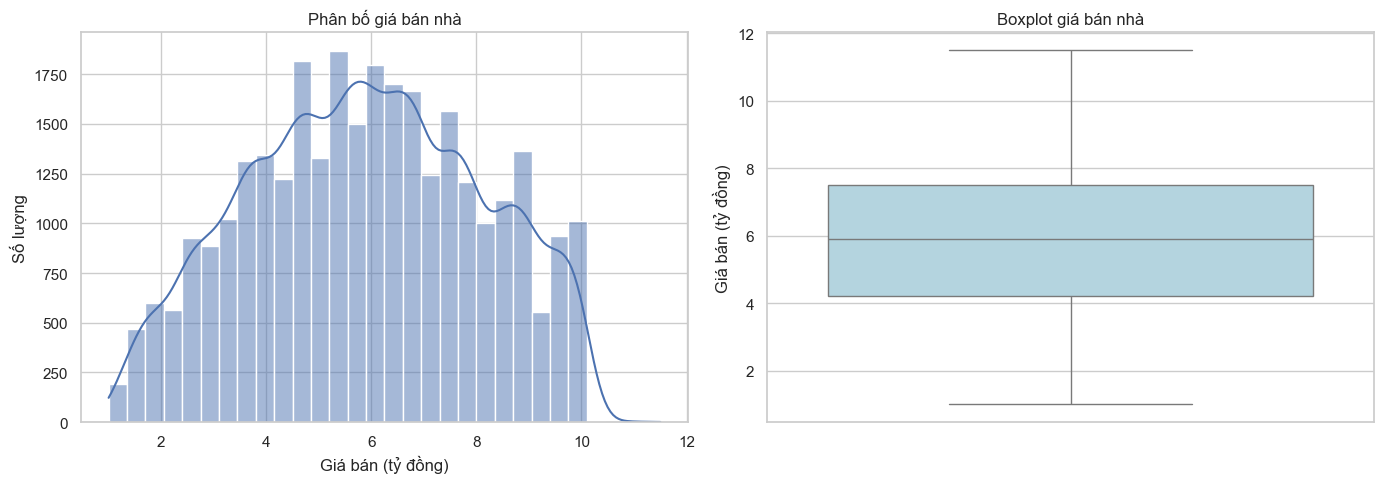

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Price'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Phân bố giá bán nhà')
axes[0].set_xlabel('Giá bán (tỷ đồng)')
axes[0].set_ylabel('Số lượng')

sns.boxplot(y=df['Price'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot giá bán nhà')
axes[1].set_ylabel('Giá bán (tỷ đồng)')

plt.tight_layout()
plt.show()

In [49]:
df[['Price', 'Price_per_m2', 'Area', 'Bedrooms', 'Bathrooms', 'Floors']].describe().T

,count,mean,std,min,25%,50%,75%,max
Price,30229.0,5.872078,2.211877,1.0,4.20,5.9,7.50,11.5
Price_per_m2,30229.0,0.107901,0.057573,0.0,0.06,0.1,0.14,1.9
Area,30229.0,68.498741,48.069835,3.1,40.00,56.0,80.00,595.0
Bedrooms,30229.0,3.423765,1.207520,1.0,3.00,3.0,4.00,9.0
Bathrooms,30229.0,3.265672,1.234208,1.0,3.00,3.0,4.00,9.0
Floors,30229.0,3.361507,1.254256,1.0,2.00,3.0,4.00,10.0


- Giá bán nhà có phân phối tập trung chủ yếu trong khoảng **4–8 tỷ đồng**, với đỉnh phân bố xấp xỉ **5–6 tỷ đồng**.
- Giá bán trải dài từ khoảng **1 tỷ đến hơn 11 tỷ đồng**, cho thấy dữ liệu bao phủ nhiều phân khúc thị trường.
- Boxplot cho thấy **giá trung vị (median)** vào khoảng **6 tỷ đồng**, nghĩa là một nửa số bất động sản có giá thấp hơn và một nửa có giá cao hơn mức này.
- Khoảng tứ phân vị (IQR) tương đối lớn, phản ánh mức độ biến động giá bán khá cao giữa các bất động sản.
- Không xuất hiện nhiều điểm ngoại lai (outlier) rõ rệt sau quá trình tiền xử lý, cho thấy dữ liệu đã được làm sạch và chuẩn hóa tương đối tốt.

## 3. Thống kê mật độ tin đăng theo Tỉnh/Thành phố

In [ ]:
# Đếm số lượng tin đăng theo từng Tỉnh/Thành phố
df['Province'].value_counts()

### Nhận xét:
- **TP. Hồ Chí Minh** (11,787 tin) và **Hà Nội** (10,463 tin) là 2 địa phương có số lượng tin bài đăng bán bất động sản cao vượt trội.
- Các tỉnh/thành tiếp theo có số lượng tin bài đáng kể gồm Bình Dương, Đà Nẵng, Đồng Nai, Hải Phòng và Khánh Hòa.

## 4. Mối quan hệ giữa diện tích và giá bán

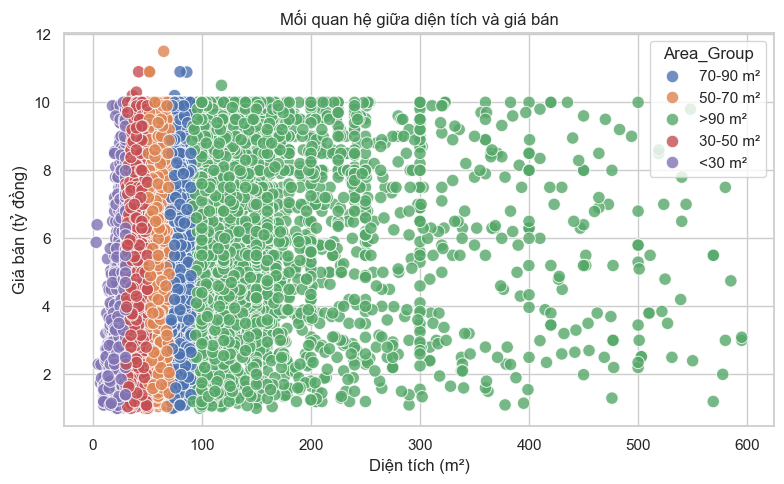

In [50]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Area', y='Price', hue='Area_Group', s=80, alpha=0.8)
plt.title('Mối quan hệ giữa diện tích và giá bán')
plt.xlabel('Diện tích (m²)')
plt.ylabel('Giá bán (tỷ đồng)')
plt.tight_layout()
plt.show()

- Diện tích và giá bán có xu hướng đồng biến nhưng **tương quan không mạnh**.
- Phần lớn dữ liệu tập trung ở các bất động sản có diện tích dưới **100 m²**.
- Nhóm bất động sản trên **90 m²** có mức giá rất đa dạng, cho thấy giá bán còn phụ thuộc vào nhiều yếu tố khác ngoài diện tích.
- Kết quả cho thấy cần kết hợp thêm các biến như **vị trí, pháp lý và dự án** để phân tích chính xác các yếu tố ảnh hưởng đến giá bán.

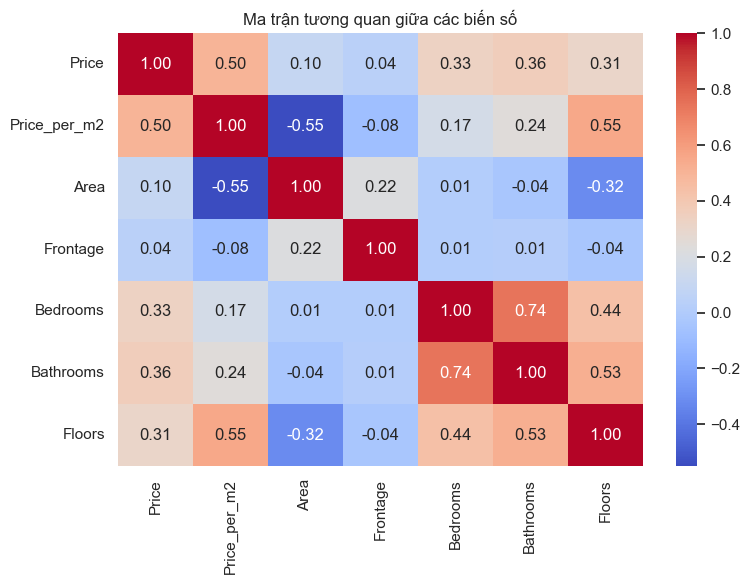

In [51]:
corr = df[['Price', 'Price_per_m2', 'Area', 'Frontage', 'Bedrooms', 'Bathrooms', 'Floors']].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các biến số')
plt.tight_layout()
plt.show()

- Không có biến nào có mối tương quan tuyến tính mạnh với **Price**. Biến có tương quan cao nhất là **Price_per_m2** (0.50), trong khi **Bedrooms**, **Bathrooms** và **Floors** chỉ có tương quan yếu đến trung bình.
- **Area** chỉ có hệ số tương quan khoảng **0.10** với **Price**, cho thấy diện tích chưa phải là yếu tố quyết định giá bán trong bộ dữ liệu. Giá nhà còn chịu ảnh hưởng bởi nhiều yếu tố khác như vị trí, dự án và tình trạng pháp lý.
- **Bedrooms** và **Bathrooms** có tương quan khá mạnh (0.74), phản ánh các căn nhà có nhiều phòng ngủ thường cũng có nhiều phòng tắm.
- **Area** có tương quan âm với **Price_per_m2** (-0.55), cho thấy các bất động sản có diện tích lớn thường có đơn giá trên mỗi mét vuông thấp hơn.
- Nhìn chung, giá bán bất động sản chịu tác động đồng thời của nhiều yếu tố, do đó cần kết hợp nhiều biến để phân tích thay vì chỉ dựa trên một đặc trưng.

## 5. Kết luận

Qua quá trình phân tích khám phá dữ liệu (EDA), có thể rút ra một số kết luận chính như sau:

- Giá bán bất động sản tập trung chủ yếu trong khoảng **4–8 tỷ đồng**, phản ánh phân khúc nhà ở trung cấp chiếm tỷ trọng lớn trong bộ dữ liệu.
- Diện tích và giá bán có xu hướng đồng biến, tuy nhiên **mối tương quan tuyến tính không mạnh**, cho thấy diện tích không phải là yếu tố duy nhất quyết định giá nhà.
- **Price_per_m2** có mối tương quan đáng kể với giá bán, trong khi các đặc điểm như số phòng ngủ, số phòng tắm và số tầng chỉ có mức ảnh hưởng yếu đến trung bình.
- Giá bất động sản chịu tác động đồng thời của nhiều yếu tố như **vị trí, dự án, tình trạng pháp lý và đặc điểm của bất động sản**, do đó cần xem xét kết hợp nhiều biến trong quá trình phân tích.
- **Nguồn cung tin đăng**: Tập trung chủ yếu ở hai đại đô thị **TP. Hồ Chí Minh** và **Hà Nội** (chiếm trên 73% tổng tin đăng), thể hiện sự phân hóa rõ rệt về quy mô giao dịch theo địa lý.